In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm

import pickle

import matplotlib.pyplot as plt
import plotly.graph_objects as go

import matplotlib.ticker as ticker
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
import colorsys

from google.cloud import bigquery

import plotly.io as pio
pio.renderers.default = 'iframe'

from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [2]:
cset_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
cset_colors = ["#0B1F41","#003DA6","#B53A6D","#7AC4A5","#F17F4C","#15AFD0","#839DC5","#E5BF21"]

In [3]:
client = bigquery.Client()

In [4]:
query_text = """

WITH
cluster_types AS (
  SELECT
    cluster_id,
    cluster_group_label,
    high_recent_activity,
  FROM IEEE_2026_paper_submission.research_activity
),
cluster_funders AS (
    SELECT
      cluster_id,
      LOGICAL_OR(resolved_funding_org = 'National Science Foundation') AS is_NSF,
       LOGICAL_OR(resolved_funding_org = 'National Institutes of Health') AS is_NIH,
        LOGICAL_OR((resolved_funding_org = 'National Science Foundation') OR (resolved_funding_org = 'National Institutes of Health')) AS is_NSFNIH,
    FROM IEEE_2026_paper_submission.nih_nsf_papers_resolved_funding
    GROUP BY cluster_id
)

SELECT
  cluster_id,
  cluster_group_label,
  high_recent_activity,
  COALESCE(is_NSF, FALSE) AS is_NSF,
  COALESCE(is_NIH, FALSE) AS is_NIH,
  COALESCE(is_NSFNIH, FALSE) AS is_NSFNIH
FROM cluster_types
FULL JOIN cluster_funders USING(cluster_id)

"""

query = client.query(query_text)
cluster_types = pd.DataFrame([{k:row[k] for k in row.keys()} for row in query])

In [5]:
cluster_types

,cluster_id,cluster_group_label,high_recent_activity,is_NSF,is_NIH,is_NSFNIH
0,58225.0,NaN,False,False,True,True
1,31149.0,NaN,False,False,False,False
2,59734.0,NaN,False,False,True,True
3,25475.0,NaN,False,False,False,False
4,46375.0,NaN,False,False,True,True
...,...,...,...,...,...,...
91590,62.0,"Very Short-history clusters, youngest 5%",True,True,True,True
91591,724.0,"Very Short-history clusters, youngest 5%",True,True,False,True
91592,826.0,"Very Short-history clusters, youngest 5%",True,True,True,True
91593,318.0,"Very Short-history clusters, youngest 5%",True,True,True,True


In [6]:
nsf_cluster_group = cluster_types[cluster_types['is_NSF']].value_counts('cluster_group_label')/sum(cluster_types['is_NSF'])
nih_cluster_group = cluster_types[cluster_types['is_NIH']].value_counts('cluster_group_label')/sum(cluster_types['is_NIH'])
nsfnih_cluster_group = cluster_types[cluster_types['is_NSFNIH']].value_counts('cluster_group_label')/sum(cluster_types['is_NSFNIH'])
nonnsf_cluster_group = cluster_types[~cluster_types['is_NSF']].value_counts('cluster_group_label')/sum(~cluster_types['is_NSF'])
nonnih_cluster_group = cluster_types[~cluster_types['is_NIH']].value_counts('cluster_group_label')/sum(~cluster_types['is_NIH'])
nonnsfnih_cluster_group = cluster_types[~cluster_types['is_NSFNIH']].value_counts('cluster_group_label')/sum(~cluster_types['is_NSFNIH'])

In [7]:
nsf_cluster_activity = cluster_types[cluster_types['is_NSF']].value_counts('high_recent_activity')/sum(cluster_types['is_NSF'])
nih_cluster_activity = cluster_types[cluster_types['is_NIH']].value_counts('high_recent_activity')/sum(cluster_types['is_NIH'])
nsfnih_cluster_activity = cluster_types[cluster_types['is_NSFNIH']].value_counts('high_recent_activity')/sum(cluster_types['is_NSFNIH'])
nonnsf_cluster_activity = cluster_types[~cluster_types['is_NSF']].value_counts('high_recent_activity')/sum(~cluster_types['is_NSF'])
nonnih_cluster_activity = cluster_types[~cluster_types['is_NIH']].value_counts('high_recent_activity')/sum(~cluster_types['is_NIH'])
nonnsfnih_cluster_activity = cluster_types[~cluster_types['is_NSFNIH']].value_counts('high_recent_activity')/sum(~cluster_types['is_NSFNIH'])

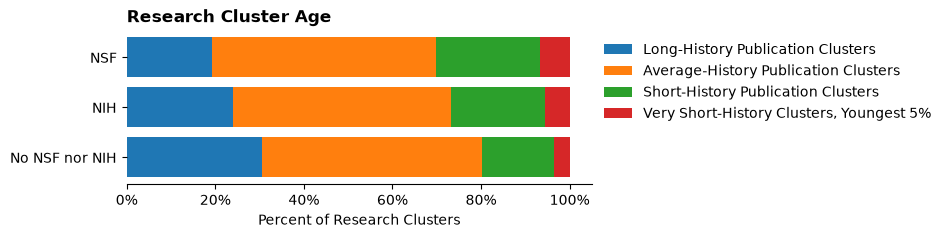

In [8]:
plt.figure(figsize=(6,2))

offset = np.array([0.0, 0.0, 0.0])
for k in ['Long-history publication clusters','Average-history publication clusters','Short-history publication clusters','Very Short-history clusters, youngest 5%']:
    labels = ['NSF','NIH','No NSF nor NIH']
    vals = np.array([
                    nsf_cluster_group[k],
                    nih_cluster_group[k],
                    nonnsfnih_cluster_group[k]
            ])
    plt.barh(labels, vals, left=offset, label=k.title())
    offset += vals
    
plt.gca().invert_yaxis()
plt.xlabel('Percent of Research Clusters')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left", frameon=False)

plt.title('Research Cluster Age', weight='bold', loc='left')
plt.gca().spines[['top','right','left']].set_visible(False)

#plt.savefig('funding_agency_research_cluster_distribution.pdf', bbox_inches='tight')
#plt.savefig('funding_agency_research_cluster_distribution.png', transparent=True, bbox_inches='tight')

plt.show()

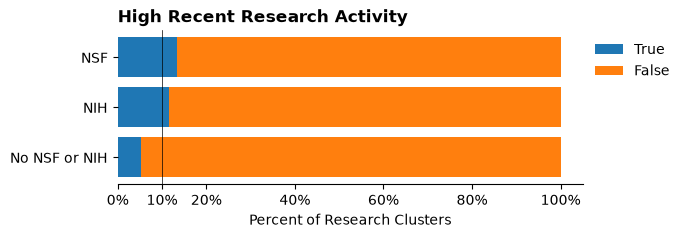

In [9]:
plt.figure(figsize=(6,2))

offset = np.array([0.0, 0.0, 0.0])
for k in [True, False]:
    labels = ['NSF','NIH', 'No NSF or NIH']
    vals = np.array([
                    nsf_cluster_activity[k],
                    nih_cluster_activity[k],
                    nonnsfnih_cluster_activity[k]
            ])
    plt.barh(labels, vals, left=offset, label=k)
    offset += vals
    
plt.gca().invert_yaxis()
plt.xlabel('Percent of Research Clusters')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left", frameon=False)

plt.axvline(x=0.1, color='black', linestyle='-', linewidth=0.5)

plt.title('High Recent Research Activity', weight='bold', loc='left')
plt.gca().spines[['top','right','left']].set_visible(False)

plt.xticks([0,0.1,0.2,0.4,0.6,0.8,1])

#plt.savefig('funding_agency_research_cluster_distribution.pdf', bbox_inches='tight')
#plt.savefig('funding_agency_research_cluster_distribution.png', transparent=True, bbox_inches='tight')

plt.show()

In [14]:
print(f'{100*nsf_cluster_activity[True]:.4f}% of NSF clusters have high recent activity, compared to {100*nonnsf_cluster_activity[True]:.4f}% of non-NSF clusters')

13.4681% of NSF clusters have high recent activity, compared to 6.3961% of non-NSF clusters


In [15]:
print(f'{100*nih_cluster_activity[True]:.4f}% of NIH clusters have high recent activity, compared to {100*nonnih_cluster_activity[True]:.4f}% of non-NIH clusters')

11.5663% of NIH clusters have high recent activity, compared to 8.2603% of non-NIH clusters


In [16]:
print(f'{100*nsfnih_cluster_activity[True]:.4f}% of NSF/NIH clusters have high recent activity, compared to {100*nonnsfnih_cluster_activity[True]:.4f}% of non-NSF/NIH clusters')

11.4131% of NSF/NIH clusters have high recent activity, compared to 5.2537% of non-NSF/NIH clusters


In [22]:
changes_df = pd.DataFrame([
    {
        'funder':'NSF',
        'frac_with_funding':nsf_cluster_activity[True],
        'frac_without_funding':nonnsf_cluster_activity[True]
    },
    {
        'funder':'NIH',
        'frac_with_funding':nih_cluster_activity[True],
        'frac_without_funding':nonnih_cluster_activity[True]
    },
    {
        'funder':'NSF or NIH',
        'frac_with_funding':nsfnih_cluster_activity[True],
        'frac_without_funding':nonnsfnih_cluster_activity[True]
    }
])
changes_df

,funder,frac_with_funding,frac_without_funding
0,NSF,0.134681,0.063961
1,NIH,0.115663,0.082603
2,NSF or NIH,0.114131,0.052537


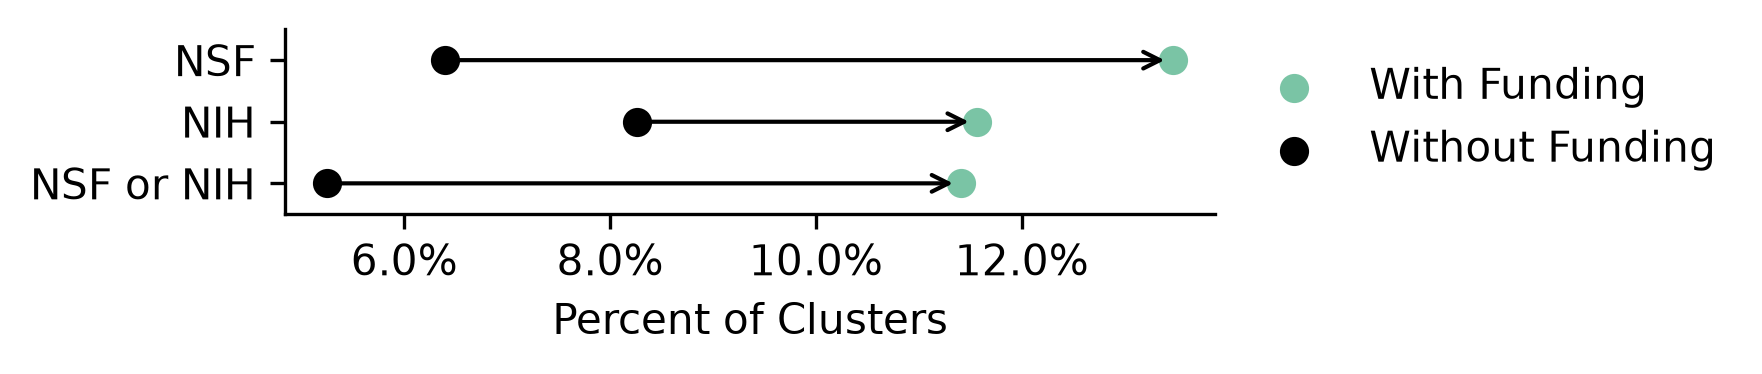

In [43]:
plt.figure(figsize=(4,0.8), dpi=300)


plt.scatter(changes_df['frac_with_funding'], changes_df.index, zorder = 2,
            c=cset_colors[3], label='With Funding')
plt.scatter(changes_df['frac_without_funding'], changes_df.index, zorder = 2,
            c='black', label='Without Funding')
for idx, row in changes_df.iterrows():
    plt.gca().annotate("", xytext=(row['frac_without_funding'], idx), xy=(row['frac_with_funding'], idx),
            arrowprops=dict(arrowstyle="->"))

plt.yticks(changes_df.index, changes_df['funder'])
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left", frameon=False)

#plt.title("High Recent Research Activity", loc='left', weight='bold')

plt.gca().spines[['top','right']].set_visible(False)
#plt.grid(axis='y')
plt.ylim([-0.5,2.5])
plt.gca().invert_yaxis()

plt.xlabel('Percent of Clusters')

plt.savefig('../figures/funder_recent_activity.png', transparent=True, bbox_inches='tight')
plt.savefig('../figures/funder_recent_activity.pdf', transparent=True, bbox_inches='tight')

plt.show()

In [21]:
changes_dict

[{'funder': 'NSF',
  'frac_with_funding': 0.1346809854706254,
  'frac_without_funding': 0.0639610021539508},
 {'funder': 'NIH',
  'frac_with_funding': 0.11566342264407865,
  'frac_without_funding': 0.08260316393403269},
 {'funder': 'NSF or NIH',
  'frac_with_funding': 0.11413149872752189,
  'frac_without_funding': 0.052537224241820626}]